### LangGraph

langgraph doc: https://docs.langchain.com/oss/python/langgraph/overview\
youtube tutorial: https://youtu.be/jGg_1h0qzaM?si=HT7f_wPOH_pDJ_do

In [25]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

#### Step 1. Setup

Langgraph consists mainly of a global ```state``` object, consider it as a structured context to be consumed by the nodes. This state is *typed* so that it can be handled cleanly! 

In [26]:
class AgentState(TypedDict): 
    message : str
    notification: str

# nodes are represented as atomic functions that can handle **state**
def greeting_node(state: AgentState) -> AgentState: 
    state["message"] = f"A notification was sent to you: {state["notification"]}"

    return state

#### Step 2. Initialize

In [27]:
graph = StateGraph(AgentState)

# graph is a very simple one:  start -> greeter -> finish

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

# alternatively: 
# graph.add_edge(START, "greeter")
# graph.add_edge("greeter", END)

app = graph.compile()

#### Step 3. Visualize and run

In [28]:
def display_app_graph():
    display(Image(app.get_graph().draw_mermaid_png()))

A notification was sent to you: Hello World!


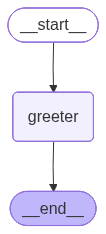

In [29]:
initial_state = {
    "notification": "Hello World!"
}

result_state = app.invoke(initial_state)
print(result_state["message"])

display_app_graph()

### Edges

In [30]:
class AgentState(TypedDict): 
    number1 : int
    number2 : int
    operation : Literal['+', '-']
    result : int

In [31]:
def adder(state: AgentState) -> AgentState:
    state["result"] = state["number1"] + state["number2"]

    return state

def subtracter(state: AgentState) -> AgentState:
    state["result"] = state["number1"] - state["number2"]

    return state

def switch(state:AgentState) -> str:
    # returns the key for the agent to forward to 
    
    if state["operation"] == "+":
        return "addition_operator"

    elif state["operator"] == "-":
        return "subtraction_operator"

In [32]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtracter)
graph.add_node("router", lambda state: state) # passthrough the state

# add_edge(node, node)
graph.add_edge(START, "router")

# conditional edge

# path_map = {"edge_name": "node"}
path_map = {
    "addition_operator": "add_node",
    "subtraction_operator": "subtract_node"
}

# add_conditional_edges("after_node", function, pathmap)
graph.add_conditional_edges(
    "router",
    switch,
    path_map,
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

the result of operation: '1 + 2' is:  3


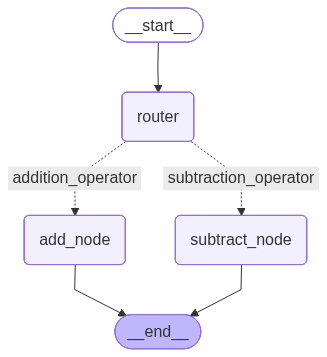

In [33]:
app = graph.compile()

initial_state = {
    "number1": 1,
    "number2": 2,
    "operation": "+"
}

result_state = app.invoke(initial_state)
print(f"the result of operation: '{result_state["number1"]} {result_state["operation"]} {result_state["number2"]}' is: ", result_state["result"])

display_app_graph()


### Loops

In [34]:
class AgentState(TypedDict): 
    greeting_message : str
    max_iter : int
    loop_counter : int
    random_array : list[int]

In [35]:
import random
from sre_parse import State

# nodes

def greeter(state:AgentState) -> AgentState:
    state["greeting_message"] = "Greetings! we're building your random array"
    return state

def random_generator(state:AgentState) -> AgentState:
    state["random_array"].append(random.randint(1, 100))
    state["loop_counter"] += 1
    return state

graph = StateGraph(AgentState)

graph.add_node("greeter_node", greeter)
graph.add_node("generator_node", random_generator)

# edges

graph.add_edge(START, "greeter_node")
graph.add_edge("greeter_node", "generator_node")

def iter_controller(state:AgentState) -> str:

    if state["loop_counter"] < state["max_iter"]: 
        return "loop"

    else:
        return "goto_end"

graph.add_conditional_edges(
    "generator_node",
    iter_controller,
    {
        "loop": "generator_node",
        "goto_end": END,
    }
)

Greetings! we're building your random array
[96, 77, 80, 52, 5, 50, 75, 91, 76, 82]


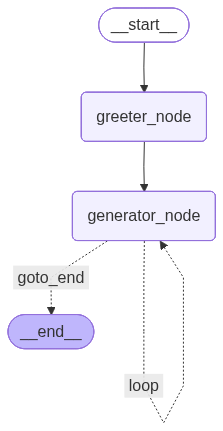

In [36]:
app = graph.compile()

initial_state = {
    "random_array": [],
    "max_iter": 10,
    "loop_counter": 0
}

result_state = app.invoke(initial_state)
print(result_state["greeting_message"])
print(result_state["random_array"])

display_app_graph()


### Agents (Finally)

The porpouse of this section is to highlight a modern agent workflow building langgraph on top of ```langchain``` agents. Langchain is a state of the art library dedicated to handle LLM api calls in a very easy-to-read way that avoids all the jargain involved when trying to implement tool calls from scratch (see function-calling-tutorial).\

It also acts as an adapter layer, so the LLM model can be swapped easily (very relevant for our use-case)

langchain doc: https://docs.langchain.com/oss/python/langchain/overview

In [37]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END 
from langgraph.prebuilt import ToolNode

In [42]:
# tools !

@tool
def add(a: int, b: int) -> int:
    """This is an addition function, returns a + b"""

    return a + b

# replace the typical description of a tool in an object, for runtime-gathered
# information, that's why we use strict type annotations as well as function descriptions!
# 
# equivalent to (for ChatGPT): 
#
# add_tool = {
#     "name": "add",
#     "description": "This is an addition function, returns a + b",
#     "parameters": {
#         "type": "object",
#         "properties": {
#             "a": {
#                 "type": "int",
#                 "description": "the first operator e.g. 1",
#             },
#             "b": {
#                 "type": "int",
#                 "description": "the second operator e.g. 2",
#             },
#         },
#         "required": ["a", "b"],
#     },
# }

@tool
def subtract(a: int, b: int) -> int:
    """This is a subtraction function, returns a - b"""

    return a - b

@tool
def abs(a: int) -> int:
    """This is an absolute value operator, returns |a|"""
    if a < 0: 
        return -a
    return a

tools = [add, subtract, abs]

In [44]:
load_dotenv()

class AgentState(TypedDict): 
    messages : Annotated[Sequence[BaseMessage], add_messages]

graph = StateGraph(AgentState)
model = ChatOpenAI(model = "gpt-4o").bind_tools(tools)

# nodes

def model_call(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(content=
        "You are an AI assistant, answer the user query to your best abillity"
    )
    # parses the content into something like: 
    # {
    #   'role': 'system',
    #   'content': system_prompt
    # }
    # but again, it depends on the model chosen. 

    response = model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

    # because the 'messages' field in our AgentState is an 'Annotated' type, it processes 
    # [response] with the 'add_messages' reduction function, so no need to parse and append
    # the response by hand!

graph.add_node("agent", model_call)

tool_node = ToolNode(tools=tools) # premade toolnode from langgraph, pretty handy
graph.add_node("tools", tool_node)

# edges
graph.add_edge(START, "agent")

def switch(state: AgentState) -> str:
    messages = state["messages"]
    last_message = messages[-1]

    if not last_message.tool_calls:
        return "goto_end"
    else:
        return "continue"

graph.add_conditional_edges(
    "agent",
    switch,
    {
        "goto_end": END,
        "continue": "tools"
    }
)

graph.add_edge("tools", "agent")

app = graph.compile()

In [45]:
initial_state = AgentState(
    messages=[("user", "solve for: the absoulte value of one minus three, then add ten")]
)

result_state = app.invoke(initial_state)
print(result_state)

{'messages': [HumanMessage(content='solve for: the absoulte value of one minus three, then add ten', additional_kwargs={}, response_metadata={}, id='244249e4-bbac-45e9-ba71-7f996ac1f4c8'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 136, 'total_tokens': 186, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fa7f5b168b', 'id': 'chatcmpl-D3ESdcbhlz7yK1NV9vyfGSAyqR1oZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c0821-8bd4-7b12-9427-11f836b9f185-0', tool_calls=[{'name': 'subtract', 'args': {'a': 1, 'b': 3}, 'id': 'call_ayVhvfdzLEwiLaK6QjSPxDcG', 'type': 'tool_call'}, {'name': 'add', 'args': {'a': 10, 'b': 3}, 

In [46]:
print(result_state["messages"][-1].content)

The absolute value of one minus three is 2. Adding ten to the result gives a total of 12.
